In [112]:
# Multilayer Perceptron
import pandas as pd
import numpy
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)
import tensorflow as tf



import tensorflow.keras
import math
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2DTranspose,Input, Reshape, Conv2D, Flatten, Activation, LeakyReLU
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import concatenate, BatchNormalization
import argparse
#from tensorflow.keras.utils.np_utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dropout
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from scipy.stats import pearsonr, spearmanr
from skimage import io

In [113]:
####################
####### Functions #############
####################

def custom_loss_2 (y_true, y_pred):
    A = tensorflow.keras.losses.mean_absolute_error(y_true, y_pred)
    #B = keras.losses.categorical_crossentropy(y_true[:,-4:], y_pred[:,-4:])
    return A





def lrelu(x): #from pix2pix code
    a=0.2
    # adding these together creates the leak part and linear part
    # then cancels them out by subtracting/adding an absolute value term
    # leak: a*x/2 - a*abs(x)/2
    # linear: x/2 + abs(x)/2

    # this block looks like it has 2 inputs on the graph unless we do this
    x = tf.identity(x)
    return (0.5 * (1 + a)) * x + (0.5 * (1 - a)) * tf.abs(x)

def lrelu_output_shape(input_shape):
    shape = list(input_shape)
    return tuple(shape)

from tensorflow.keras.layers import Lambda
layer_lrelu=Lambda(lrelu, output_shape=lrelu_output_shape, name='Leaky_ReLU')


def createOutputLabels(Labels):
    output=np.zeros(shape=(len(Labels),12))    
    
    for i in range(len(Labels)):
        for j in range (4):
            if Labels.iloc[i,j]=='CN':
                output[i,j*3]=1
                output[i,j*3+1]=0
                output[i,j*3+2]=0

                
            elif Labels.iloc[i,j]=='MCI':
                output[i,j*3]=0
                output[i,j*3+1]=1
                output[i,j*3+2]=0
                
            elif Labels.iloc[i,j]=='AD':
                output[i,j*3]=0
                output[i,j*3+1]=0
                output[i,j*3+2]=1
                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output

def create_image(labels):
    output=np.zeros(shape=(len(labels),3,4,3))    
    
    for i in range(len(labels)):
        for j in range (3):
                if j ==0:
                    output[i,j,:,1] = labels[i,j]
                elif j==1:
                     output[i,j,:,2] = labels[i,j]
                elif j ==2:
                    output[i,j,:,0] = labels[i,j]

                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output



def FnCreateValidLabes(Labels):
    return range(len(Labels))

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def box_subplot(df1, df2, features, modality_name):

    # Define custom light/dark colors per DX group
    color_map = {
        'CN': ('#90ee90', '#006400'),        # light green, dark green
        'MCI': ('#add8e6', '#00008b'),       # light blue, dark blue
        'Dementia': ('#f08080', '#8b0000')   # light coral, dark red
    }

    n = len(features)
    cols = 2
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = axes.flatten()

    handles, labels = None, None

    for i, feature in enumerate(features):
        # Prepare data
        df1_subset = df1[['DX', feature]].copy()
        df1_subset['Source'] = 'Before'
        df1_subset.rename(columns={feature: 'Value'}, inplace=True)

        df2_subset = df2[['DX', feature]].copy()
        df2_subset['Source'] = 'After'
        df2_subset.rename(columns={feature: 'Value'}, inplace=True)

        # Reset index to avoid duplicate index errors
        combined = pd.concat([df1_subset, df2_subset], ignore_index=True)

        # Create combined label
        combined['Group'] = combined['DX'] + ' - ' + combined['Source']

        # Build color palette manually (no dictionary merging)
        group_palette = {
            'CN - Before': color_map['CN'][0],
            'CN - After': color_map['CN'][1],
            'MCI - Before': color_map['MCI'][0],
            'MCI - After': color_map['MCI'][1],
            'Dementia - Before': color_map['Dementia'][0],
            'Dementia - After': color_map['Dementia'][1],
        }

        hue_order = [
            'CN - Before', 'CN - After',
            'MCI - Before', 'MCI - After',
            'Dementia - Before', 'Dementia - After'
        ]

        sns.boxplot(
        data=combined,
        x='Group',
        y='Value',
        hue='Group',
        order=hue_order,
        palette=group_palette,
        ax=axes[i],
        fliersize=3,
        linewidth=1.2,
        legend=False  # <--- suppress legend to avoid redundancy
    )

        axes[i].set_title(feature, fontsize=13)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('', fontsize=11)
        axes[i].tick_params(axis='x', labelsize=10)
        axes[i].tick_params(axis='y', labelsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.3)

        # Store legend
        if handles is None or labels is None:
            handles, labels = axes[i].get_legend_handles_labels()

        if axes[i].legend_ is not None:
            axes[i].legend_.remove()

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Shared legend
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=3,
        fontsize=11,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01)
    )

    # Overall title and layout
    fig.suptitle(f'{modality_name} Distribution by Diagnosis (Before and After Imputation)', fontsize=16, y=0.99)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [59]:
n_splits=10


In [115]:
####################
###### Reading Data ##############    
####################    

# AllDataset = pandas.read_csv('Data_XY_BLD_CutOff.csv', low_memory=False)
AllDataset = pd.read_csv('dataset_imputed_outlier_removed_final.csv', low_memory=False)
AllDataset = AllDataset.set_index(AllDataset.ID)

OriginalDataset = pd.read_excel('dataset_final.xlsx')
OriginalDataset = OriginalDataset.set_index(OriginalDataset.ID)

In [33]:
len(AllDataset)

5593

In [116]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [117]:
regions = ['Ventricles/ICV', 'Hippocampus/ICV', 'WholeBrain/ICV', 'Entorhinal/ICV', 'Fusiform/ICV', 'MidTemp/ICV']
volume_means = AllDataset.groupby('DX')[regions].mean().round(4)
volume_means

,Ventricles/ICV,Hippocampus/ICV,WholeBrain/ICV,Entorhinal/ICV,Fusiform/ICV,MidTemp/ICV
DX,,,,,,
AD,0.0339,0.0036,0.6229,0.0018,0.0097,0.0108
CN,0.0231,0.0048,0.6717,0.0025,0.0117,0.0132
MCI,0.0261,0.0044,0.6663,0.0023,0.0114,0.0127


In [118]:
import pandas as pd

regions = ['Ventricles/ICV', 'Hippocampus/ICV', 'WholeBrain/ICV', 'Entorhinal/ICV', 'Fusiform/ICV', 'MidTemp/ICV',
           'FDG', 'AV45',
           'CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting','RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR','TRABSCOR',
           'ABETA', 'PTAU', 'TAU', 'AGE', 'PTEDUCAT', 'APOE4']
dx_order = ['CN', 'MCI', 'AD']  # Desired DX order

# Collect stats
summary_rows = []

for dx, group in AllDataset.groupby('DX'):
    for region in regions:
        values = group[region]
        summary_rows.append({
            'Region': region,
            'DX': dx,
            'mean': values.mean(),
            'q1': values.quantile(0.25),
            'q2': values.median(),
            'q3': values.quantile(0.75)
        })

# Create DataFrame
summary_df = pd.DataFrame(summary_rows)

# Convert DX to categorical with order
summary_df['DX'] = pd.Categorical(summary_df['DX'], categories=dx_order, ordered=True)

# Sort by Region, then DX
summary_df = summary_df.sort_values(by=['Region', 'DX'])

# Set MultiIndex and round
summary_df.set_index(['Region', 'DX'], inplace=True)
summary_df = summary_df.round(4)

# Show the final result
print(summary_df)


                        mean       q1        q2        q3
Region         DX                                        
ABETA          CN  1203.8133 831.3000 1270.0000 1689.2632
               MCI  972.9944 613.3500  845.8000 1359.8750
               AD   634.8277 445.0500  567.5500  735.4500
AGE            CN    76.3224  72.4000   76.3000   80.4000
               MCI   74.5346  69.1000   74.8000   80.3000
...                      ...      ...       ...       ...
Ventricles/ICV MCI    0.0261   0.0166    0.0238    0.0332
               AD     0.0339   0.0240    0.0318    0.0416
WholeBrain/ICV CN     0.6717   0.6383    0.6732    0.7025
               MCI    0.6663   0.6277    0.6637    0.7060
               AD     0.6229   0.5906    0.6199    0.6528

[75 rows x 4 columns]


In [28]:
summary_df.to_csv('summary_statistics.csv')

In [119]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1373, 'missing_counts': Ventricles/ICV           272
Hippocampus/ICV          349
WholeBrain/ICV           248
Entorhinal/ICV           379
Fusiform/ICV             379
MidTemp/ICV              379
FDG                      625
AV45                     567
CDRSB                      1
MMSE                       0
RAVLT_immediate            0
RAVLT_learning             0
RAVLT_forgetting           0
RAVLT_perc_forgetting      0
FAQ                        1
MOCA                     213
LDELTOTAL                  0
DIGITSCOR                508
TRABSCOR                   0
ABETA                    676
PTAU                     676
TAU                      676
AGE                        0
PTEDUCAT                   0
APOE4                      0
dtype: int64}, 'AD': {'total_subjects': 2187, 'missing_counts': Ventricles/ICV            680
Hippocampus/ICV           879
WholeBrain/ICV            617
Entorhinal/ICV            995
Fusiform/ICV              995
MidTemp/ICV

In [111]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )


In [42]:
###################### MRI ######################

# Select relevant MRI features
MRI_X = AllDataset.loc[:, ['Ventricles/ICV', 'Hippocampus/ICV', 'WholeBrain/ICV', 'Entorhinal/ICV', 'Fusiform/ICV', 'MidTemp/ICV']]


# Extract diagnosis-related columns
MRI_Y = AllDataset.loc[:, ['DX', 'DX6', 'DX12', 'DX24']]

# Extract ID column
MRI_ID = AllDataset.ID

# Normalize the MRI features: mean-centering and scaling by range
MRI_X = (MRI_X - MRI_X.min()) / (MRI_X.max() - MRI_X.min())


# Display summary statistics
MRI_X.head()


,Ventricles/ICV,Hippocampus/ICV,WholeBrain/ICV,Entorhinal/ICV,Fusiform/ICV,MidTemp/ICV
ID,,,,,,
1,0.6599,0.5164,0.3831,0.4608,0.2569,0.6292
2,0.2227,0.6278,0.5203,0.5850,0.5408,0.5640
3,0.2227,0.6278,0.5203,0.5850,0.5408,0.5640
4,0.2227,0.6278,0.5203,0.5850,0.5408,0.5640
5,0.2227,0.6278,0.5203,0.5850,0.5408,0.5640


In [43]:
regions = ['FDG', 'AV45']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,FDG,AV45
DX,,
AD,1.0546,1.3790
CN,1.3012,1.0955
MCI,1.2395,1.1764


In [44]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1373, 'missing_counts': FDG     625
AV45    567
dtype: int64}, 'AD': {'total_subjects': 2187, 'missing_counts': FDG     1214
AV45    1691
dtype: int64}, 'MCI': {'total_subjects': 2033, 'missing_counts': FDG     831
AV45    954
dtype: int64}}


In [45]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [46]:
###################### PET ######################
PET_X = AllDataset.loc[:,['FDG', 'AV45']]
PET_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
PET_ID = AllDataset.ID


# normalize data
PET_X = (PET_X - PET_X.min()) / (PET_X.max() - PET_X.min())
PET_X.head(5)

,FDG,AV45
ID,,
1,0.7292,0.1563
2,0.5895,0.1563
3,0.6714,0.1563
4,0.6714,0.1563
5,0.6714,0.1563


In [47]:
regions = ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
DX,,,,,,,,,,,
AD,5.8167,21.5009,20.5401,1.6847,4.3004,93.1980,16.3835,16.4698,1.4466,26.9465,205.9441
CN,0.0771,29.1164,45.9193,5.9334,3.4400,32.0352,0.2173,26.0998,14.1222,48.7124,78.5587
MCI,1.5465,27.5990,34.7218,4.1468,4.6834,61.2061,3.3128,24.0949,7.1350,38.9430,113.2548


In [48]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1373, 'missing_counts': CDRSB                      1
MMSE                       0
RAVLT_immediate            0
RAVLT_learning             0
RAVLT_forgetting           0
RAVLT_perc_forgetting      0
FAQ                        1
MOCA                     213
LDELTOTAL                  0
DIGITSCOR                508
TRABSCOR                   0
dtype: int64}, 'AD': {'total_subjects': 2187, 'missing_counts': CDRSB                       5
MMSE                        4
RAVLT_immediate            22
RAVLT_learning             22
RAVLT_forgetting           30
RAVLT_perc_forgetting      53
FAQ                         5
MOCA                     1124
LDELTOTAL                 210
DIGITSCOR                 765
TRABSCOR                  148
dtype: int64}, 'MCI': {'total_subjects': 2033, 'missing_counts': CDRSB                       0
MMSE                        0
RAVLT_immediate             0
RAVLT_learning              0
RAVLT_forgetting            0
RAVLT_perc_forgetting 

In [49]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [50]:
###################### COG ######################
COG_X = AllDataset.loc[:, ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']]




COG_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
COG_RID = AllDataset.ID

# normalize data
COG_X = (COG_X - COG_X.min()) / (COG_X.max() - COG_X.min())
COG_X.head()

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
ID,,,,,,,,,,,
1,0.0000,0.9440,0.6419,0.4737,0.6646,0.2362,0.0517,0.6600,0.4792,0.6913,0.2623
2,0.0000,0.9440,0.5957,0.4211,0.5528,0.2102,0.0517,0.6531,0.5321,0.6596,0.2715
3,0.0000,0.9720,0.5263,0.3684,0.7019,0.2866,0.0517,0.6188,0.5833,0.6860,0.2729
4,0.0000,0.9440,0.5610,0.5263,0.5901,0.2140,0.0517,0.5843,0.5486,0.6875,0.3006
5,0.0261,0.8600,0.5726,0.4211,0.6646,0.2548,0.0517,0.5347,0.5486,0.6941,0.3014


In [51]:
regions = ['ABETA', 'PTAU', 'TAU']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,ABETA,PTAU,TAU
DX,,,
AD,634.8277,35.5371,362.4038
CN,1203.8133,22.8315,247.4639
MCI,972.9944,27.5313,287.9782


In [52]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1373, 'missing_counts': ABETA    676
PTAU     676
TAU      676
dtype: int64}, 'AD': {'total_subjects': 2187, 'missing_counts': ABETA    1459
PTAU     1459
TAU      1459
dtype: int64}, 'MCI': {'total_subjects': 2033, 'missing_counts': ABETA    1054
PTAU     1055
TAU      1054
dtype: int64}}


In [53]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [54]:
###################### CSF ######################
CSF_X = AllDataset.loc[:,['ABETA', 'PTAU', 'TAU']]
CSF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
CSF_RID = AllDataset.ID


# normalize data
CSF_X = (CSF_X - CSF_X.min()) / (CSF_X.max() - CSF_X.min())
CSF_X.head()

,ABETA,PTAU,TAU
ID,,,
1,0.5226,0.1500,0.1936
2,0.5226,0.1500,0.1936
3,0.5226,0.1500,0.1936
4,0.5226,0.1500,0.1936
5,0.5226,0.1500,0.1936


In [55]:
regions = ['AGE','PTEDUCAT']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,AGE,PTEDUCAT
DX,,
AD,76.5965,15.4408
CN,76.3224,16.4443
MCI,74.5346,15.9857


In [56]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1373, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'AD': {'total_subjects': 2187, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'MCI': {'total_subjects': 2033, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}}


In [57]:
###################### Risk Factor ######################
RF_X_1 = AllDataset.loc[:,['AGE','PTEDUCAT']]

RF_X_A = AllDataset.loc[:,['APOE4']]# ,'PTEDUCAT']] 


RF_X_gender = AllDataset.loc[:,['PTGENDER']]
RF_X_gender[RF_X_gender=='Male']=1
RF_X_gender[RF_X_gender=='Female']=2
RF_X_gender=RF_X_gender.fillna(3)

import pandas as pd
# RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender, RF_X_marry ], axis=1)#, RF_X_sex
RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender ], axis=1)#, RF_X_sex



# normalize data
RF_X = (RF_X - RF_X.min()) / (RF_X.max() - RF_X.min())


RF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
RF_ID = AllDataset.ID

RF_X.head(20)

,AGE,PTEDUCAT,APOE4,PTGENDER
ID,,,,
1,0.4707,0.7500,0.0000,0.0000
2,0.4829,0.7500,0.0000,0.0000
3,0.5439,0.7500,0.0000,0.0000
4,0.5927,0.7500,0.0000,0.0000
5,0.6659,0.7500,0.0000,0.0000
6,0.6415,0.8750,0.5000,0.0000
7,0.6537,0.8750,0.5000,0.0000
8,0.6659,0.8750,0.5000,0.0000
9,0.6902,0.8750,0.5000,0.0000


In [58]:
########################################
############## dataset cleaning #######
########################################

Labels_all_3class=COG_Y.iloc[:,-4:]

Labels_all_3class


,DX,DX6,DX12,DX24
ID,,,,
1,CN,CN,CN,CN
2,CN,CN,CN,CN
3,CN,CN,CN,CN
4,CN,CN,CN,MCI
5,CN,CN,CN,CN
...,...,...,...,...
5612,AD,AD,AD,AD
5613,AD,AD,AD,AD
5614,AD,AD,AD,AD


In [89]:
########################################
############## genreating input outputs from data #######
########################################

TargetTensors=createOutputLabels(Labels_all_3class)
#plt.imshow(TargetTensors[11,:,:,:])
#print(Labels_all_4class.iloc[11])


X_all=[MRI_X.values, PET_X.values, COG_X.values, 
       CSF_X.values, RF_X.values]

YTrain = COG_Y
YTrain1 = YTrain.reset_index()
Y_all_tensors=TargetTensors
X_all_IDs=RF_ID.values

In [90]:
Y_all_tensors

array([[1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.]])

In [91]:
from tensorflow.keras import backend as K

def grouped_softmax(x):
    """
    Activation function that applies softmax separately to groups of neurons
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        x: Input tensor
        
    Returns:
        Tensor with grouped softmax applied
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    group_outputs = []
    
    # Apply softmax to each group
    for start, end in groups:
        group = x[..., start:end]
        group_softmax = K.softmax(group, axis=-1)
        group_outputs.append(group_softmax)
    
    # Concatenate all groups back together
    return K.concatenate(group_outputs, axis=-1)

In [92]:
from tensorflow.keras.layers import Dropout
import tensorflow.keras.backend as K

class MCDropout(Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

In [93]:
######################################################################################
################## NEtwork Architecture ##################################################
##########################################################################################

####################################### MRI FCN ###############################################


# mri FCN

def create_model():
    MRI_inp_dim = MRI_X.shape[1]
    MRI_visible = Input(shape=(MRI_inp_dim,), name='MRI')
    hiddenMRI1 = Dense(32)(MRI_visible)
    # hiddenMRI1 = LeakyReLU(alpha=0.5)(hiddenMRI1)
    hiddenMRI1 = Activation('relu')(hiddenMRI1)
    hiddenMRI1 = Dropout(0.2)(hiddenMRI1)
    hiddenMRI2 = Dense(64)(hiddenMRI1)
    # hiddenMRI2 = LeakyReLU(alpha=0.2)(hiddenMRI2)
    hiddenMRI2 = Activation('relu')(hiddenMRI2)
    hiddenMRI2 = Dropout(0.2)(hiddenMRI2)
    MRI_output = Dense(128, activation='relu')(hiddenMRI2)

    ####################################### PET FCN ###############################################
    PET_inp_dim = PET_X.shape[1]
    PET_visible = Input(shape=(PET_inp_dim,), name='PET')
    hiddenPET1 = Dense(32)(PET_visible)
    # hiddenPET1 = LeakyReLU(alpha=0.5)(hiddenPET1)
    hiddenPET1 = Activation('relu')(hiddenPET1)
    hiddenPET1 = Dropout(0.2)(hiddenPET1)
    hiddenPET2 = Dense(64)(hiddenPET1)
    # hiddenPET2 = LeakyReLU(alpha=0.2)(hiddenPET2)
    hiddenPET2 = Activation('relu')(hiddenPET2)
    hiddenPET2 = Dropout(0.2)(hiddenPET2)
    PET_output = Dense(128, activation='relu')(hiddenPET2)

    ####################################### COG FCN ###############################################
    # mri FCN
    COG_inp_dim = COG_X.shape[1]
    COG_visible = Input(shape=(COG_inp_dim,), name='COG')
    hiddenCOG1 = Dense(32)(COG_visible)
    # hiddenCOG1 = LeakyReLU(alpha=0.5)(hiddenCOG1)
    hiddenCOG1 = Activation('relu')(hiddenCOG1)
    hiddenCOG1 = Dropout(0.2)(hiddenCOG1)
    hiddenCOG2 = Dense(64)(hiddenCOG1)
    # hiddenCOG2 = LeakyReLU(alpha=0.2)(hiddenCOG2)
    hiddenCOG2 = Activation('relu')(hiddenCOG2)
    hiddenCOG2 = Dropout(0.2)(hiddenCOG2)
    COG_output = Dense(128, activation='relu')(hiddenCOG2)

    ####################################### CSF FCN ###############################################
    CSF_inp_dim = CSF_X.shape[1]
    CSF_visible = Input(shape=(CSF_inp_dim,), name='CSF')
    hiddenCSF1 = Dense(32)(CSF_visible)
    # hiddenCSF1 = LeakyReLU(alpha=0.5)(hiddenCSF1)
    hiddenCSF1 = Activation('relu')(hiddenCSF1)
    hiddenCSF1 = Dropout(0.2)(hiddenCSF1)
    hiddenCSF2 = Dense(64)(hiddenCSF1)
    # hiddenCSF2 = LeakyReLU(alpha=0.2)(hiddenCSF2)
    hiddenCSF2 = Activation('relu')(hiddenCSF2)
    hiddenCSF2 = Dropout(0.2)(hiddenCSF2)
    CSF_output = Dense(128, activation='relu')(hiddenCSF2)

    ####################################### RF FCN ###############################################
    RF_inp_dim = RF_X.shape[1]
    RF_visible = Input(shape=(RF_inp_dim,), name='RF')
    hiddenRF1 = Dense(32)(RF_visible)
    # hiddenRF1 = LeakyReLU(alpha=0.5)(hiddenRF1)
    hiddenRF1 = Activation('relu')(hiddenRF1)
    hiddenRF1 = Dropout(0.2)(hiddenRF1)
    hiddenRF2 = Dense(64)(hiddenRF1)
    # hiddenRF2 = LeakyReLU(alpha=0.2)(hiddenRF2)
    hiddenRF2 = Activation('relu')(hiddenRF2)
    hiddenRF2 = Dropout(0.2)(hiddenRF2)
    RF_output = Dense(128, activation='relu')(hiddenRF2)

    #################################### Concat FCN ###############################################

    merge = concatenate([MRI_output, PET_output, COG_output, CSF_output,RF_output])
    merge = BatchNormalization()(merge)
    merge = Activation('relu')(merge)
    merge = Dropout(0.15)(merge)
    # interpretation layer
    # hidden1 = Dense(512, activation='relu')(merge)
    # hidden1 = Dropout(0.15)(hidden1)

    hidden2 = Dense(256, activation='relu')(merge)
    hidden2 = Dropout(0.2)(hidden2)

    hidden3 = Dense(128, activation='relu')(hidden2)
    hidden3 = Dropout(0.2)(hidden3)

    hidden4 = Dense(64)(hidden3)
    # hidden4 = BatchNormalization()(hidden4)
    hidden4 = Activation('relu')(hidden4)
    hidden4 = Dropout(0.25)(hidden4)

    hidden5 = Dense(32, activation='relu')(hidden4)
    hidden5 = Dropout(0.25)(hidden5)

    output = Dense(12, activation = grouped_softmax)(hidden5)
    model_tensorization=Model(inputs= [MRI_visible, PET_visible, COG_visible, CSF_visible, RF_visible], outputs=output)  
    return model_tensorization


model_tensorization = create_model()
model_tensorization.summary()
#dot_img_file = 'Network_23x23.png'


Model: "model_12"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 MRI (InputLayer)               [(None, 6)]          0           []                               
                                                                                                  
 PET (InputLayer)               [(None, 2)]          0           []                               
                                                                                                  
 COG (InputLayer)               [(None, 11)]         0           []                               
                                                                                                  
 CSF (InputLayer)               [(None, 3)]          0           []                               
                                                                                           

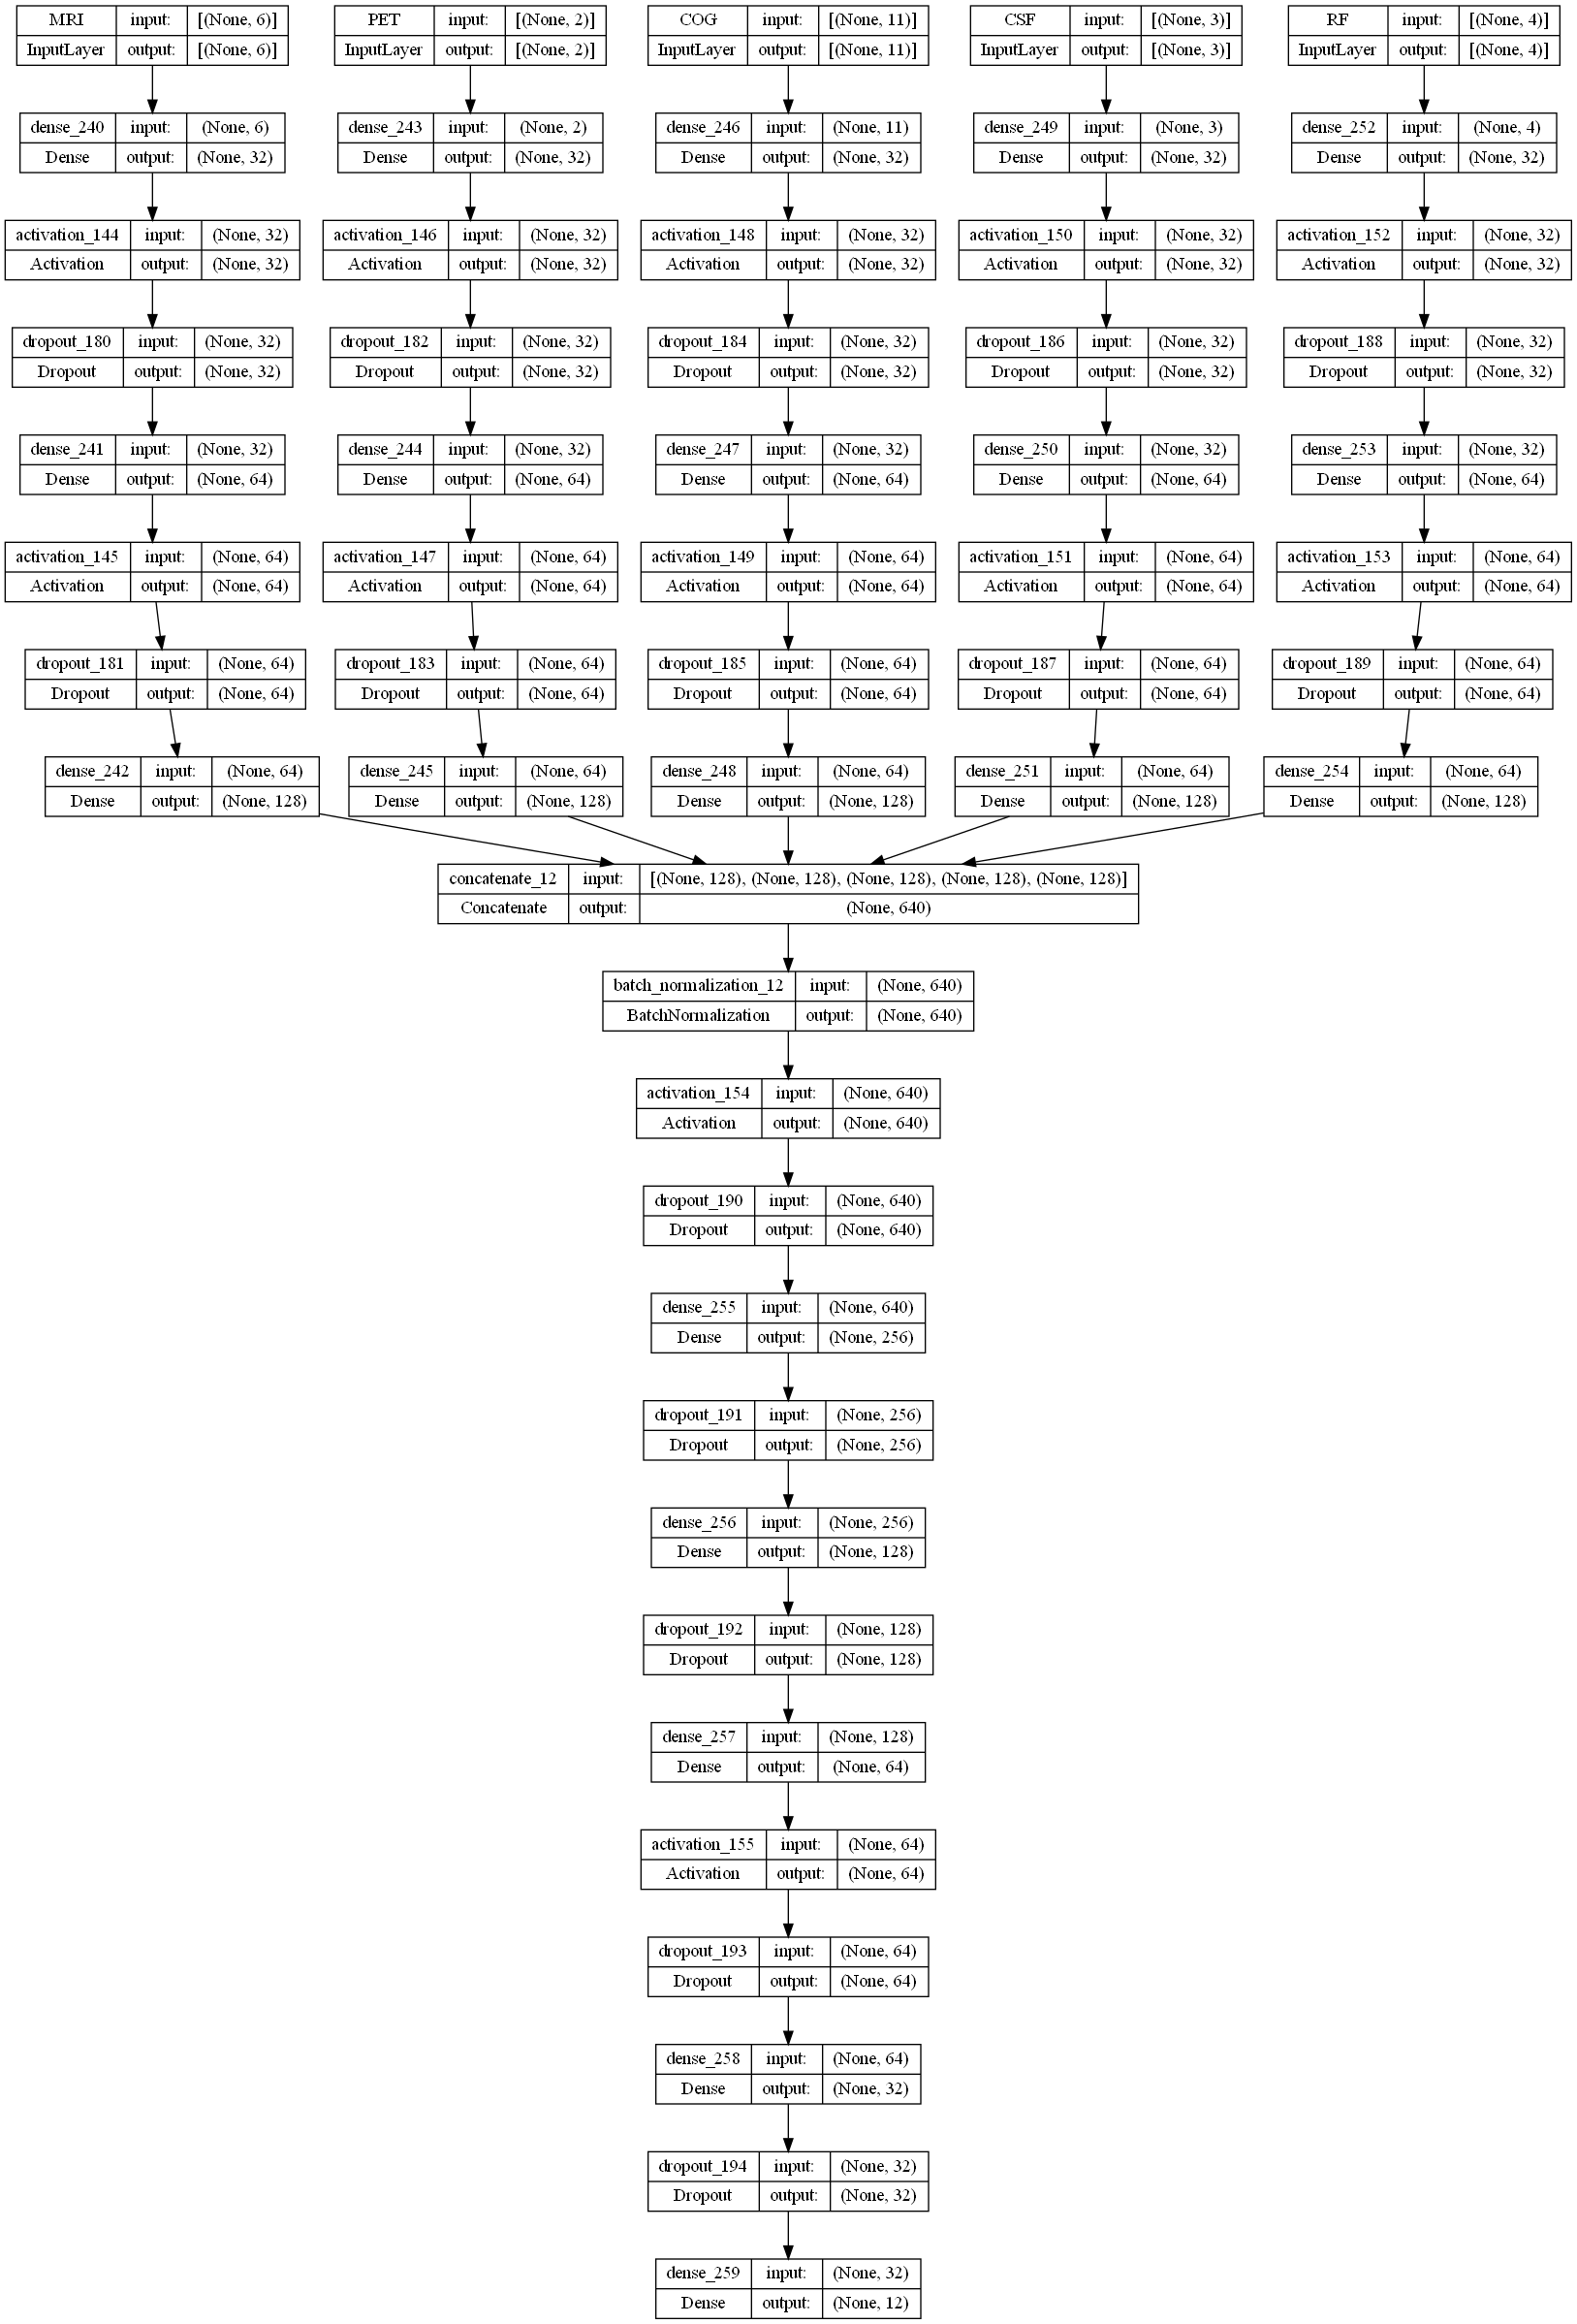

In [94]:
from tensorflow.keras.utils import plot_model

# Save the model architecture as a PNG file
plot_model(model_tensorization, to_file='model_tree.png', show_shapes=True, show_layer_names=True)

In [95]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

def grouped_categorical_crossentropy(y_true, y_pred):
    """
    Custom loss function that calculates average categorical cross entropy for groups of outputs.
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        y_true: Ground truth values, shape (batch_size, num_classes)
        y_pred: Predicted values, shape (batch_size, num_classes)
        
    Returns:
        Average of categorical cross entropy losses across the groups
    """
    # Initialize categorical cross entropy loss function
    cce = CategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
    
    # Define groups of indices
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    
    # Compute CCE loss for each group
    group_losses = []
    for start, end in groups:
        loss = cce(y_true[..., start:end], y_pred[..., start:end])
        group_losses.append(loss)
    
    # Stack losses and compute the mean across groups
    all_losses = tf.stack(group_losses, axis=-1)  # Shape: (batch_size, num_groups)
    mean_loss_per_sample = tf.reduce_mean(all_losses, axis=-1)  # Mean across groups

    # Final mean across the batch
    final_loss = tf.reduce_mean(mean_loss_per_sample)  
    
    return final_loss


In [96]:
import tensorflow as tf

def grouped_categorical_accuracy(y_true, y_pred):
    """
    Computes average categorical accuracy for grouped outputs:
    Groups: [0-2], [3-5], [6-8], [9-11]
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    accuracies = []

    for start, end in groups:
        true_group = y_true[..., start:end]
        pred_group = y_pred[..., start:end]

        # Convert one-hot to class indices
        true_labels = tf.argmax(true_group, axis=-1)
        pred_labels = tf.argmax(pred_group, axis=-1)

        acc = tf.cast(tf.equal(true_labels, pred_labels), tf.float32)
        accuracies.append(acc)

    # Stack group accuracies and compute mean per sample
    all_accuracies = tf.stack(accuracies, axis=-1)  # (batch_size, num_groups)
    mean_accuracy = tf.reduce_mean(all_accuracies, axis=-1)  # Mean per sample

    # Final mean across batch
    return tf.reduce_mean(mean_accuracy)


In [97]:
from sklearn.model_selection import train_test_split
x = np.arange(0, len(X_all[1]),1)
train, test = train_test_split(x, shuffle=True, random_state=7, test_size=0.1)

# move_ids = {4332, 5080, 3386, 4477, 4473, 4229}
move_ids = {4442, 4303, 4202, 5040, 3368, 4446}
# Convert train and test to lists temporarily
train_list = train.tolist()
test_list = test.tolist()

# Move matching IDs
moving = [id for id in train_list if id in move_ids]
train_list = [id for id in train_list if id not in move_ids]
test_list.extend(moving)

# Convert back to NumPy arrays
train = np.array(train_list)
test = np.array(test_list)


Y_train_here_4Net=Y_all_tensors[train]
X_train_here_4Net=[X_all[0][train], X_all[1][train], X_all[2][train], X_all[3][train],X_all[4][train]]
X_train_here_names=X_all_IDs[train]

In [98]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
import time
import os

# Number of folds
num_folds = 10

# Directory to save best models
os.makedirs("saved_models_kfold", exist_ok=True)

# K-Fold cross-validator
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# For tracking performance
fold_accuracies = []
fold_losses = []
all_histories = []

# K-Fold loop
for fold, (train, test) in enumerate(kfold.split(X_all[1], COG_Y.iloc[:,-1].values)):
    print(f'\n=== Training Fold {fold + 1} ===')



    Y_train_fold=Y_all_tensors[train]
    X_train_fold=[X_all[0][train], X_all[1][train], X_all[2][train], X_all[3][train],X_all[4][train]]

    X_val_fold = [X_all[0][test], X_all[1][test], X_all[2][test], X_all[3][test],X_all[4][test]]
    Y_val_fold = Y_all_tensors[test]

    # Reinitialize a fresh model instance
    model = create_model()
    model.compile(loss=grouped_categorical_crossentropy,
                  optimizer='adam',
                  metrics=[grouped_categorical_accuracy])

    # Define callbacks
    model_path = f"saved_models_kfold/best_model_fold_{fold+1}.h5"
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        model_path, monitor='val_loss', save_best_only=True, verbose=1)
    reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.9, patience=10, min_lr=1e-6, verbose=1)
    early_stop_cb = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)

    # Train the model
    start_time = time.time()
    history = model.fit(
        X_train_fold, Y_train_fold,
        validation_split=0.1,
        epochs=600,
        batch_size=64,
        verbose=1,
        callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb]
    )
    elapsed_time = time.time() - start_time
    print(f'--- Fold {fold + 1} training time: {elapsed_time:.2f} seconds')

    # Evaluate the best model
    best_model = tf.keras.models.load_model(model_path,
                                            custom_objects={
                                                'grouped_categorical_crossentropy': grouped_categorical_crossentropy,
                                                'grouped_categorical_accuracy': grouped_categorical_accuracy,
                                                'grouped_softmax': grouped_softmax
                                            })
    val_loss, val_accuracy = best_model.evaluate(X_val_fold, Y_val_fold, verbose=0)
    fold_losses.append(val_loss)
    fold_accuracies.append(val_accuracy)

    # Store history
    all_histories.append(history.history)

# Print cross-validation summary
print('\n=== Cross-Validation Summary ===')
print(f'Average Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}')
print(f'Average Loss: {np.mean(fold_losses):.4f} ± {np.std(fold_losses):.4f}')



=== Training Fold 1 ===
Epoch 1/600
70/71 [============================>.] - ETA: 0s - loss: 0.8835 - grouped_categorical_accuracy: 0.5349
Epoch 1: val_loss improved from inf to 0.69949, saving model to saved_models_kfold\best_model_fold_1.h5
71/71 [==============================] - 6s 35ms/step - loss: 0.8823 - grouped_categorical_accuracy: 0.5362 - val_loss: 0.6995 - val_grouped_categorical_accuracy: 0.7077 - lr: 0.0010
Epoch 2/600
70/71 [============================>.] - ETA: 0s - loss: 0.5967 - grouped_categorical_accuracy: 0.7191
Epoch 2: val_loss improved from 0.69949 to 0.57734, saving model to saved_models_kfold\best_model_fold_1.h5
71/71 [==============================] - 1s 20ms/step - loss: 0.5991 - grouped_categorical_accuracy: 0.7189 - val_loss: 0.5773 - val_grouped_categorical_accuracy: 0.8473 - lr: 0.0010
Epoch 3/600
71/71 [==============================] - ETA: 0s - loss: 0.5099 - grouped_categorical_accuracy: 0.7773
Epoch 3: val_loss did not improve from 0.57734
71/71

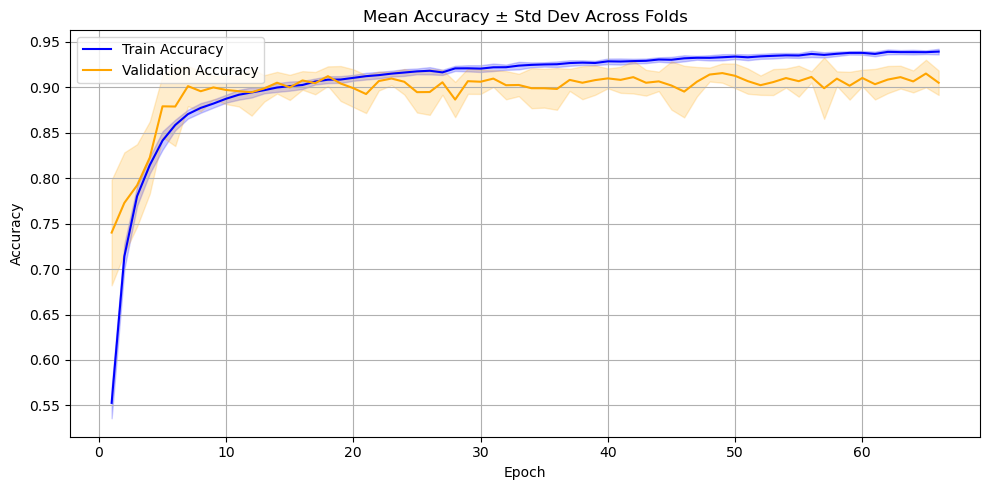

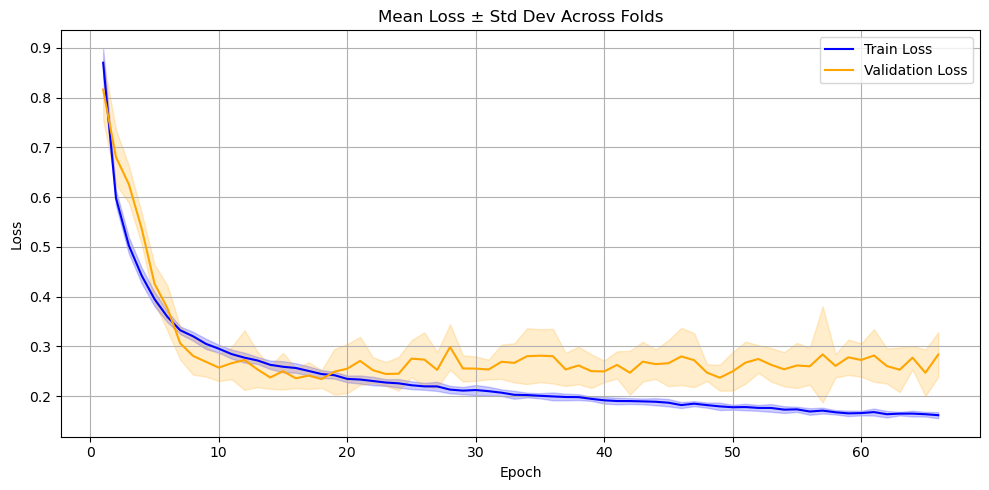

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Get the minimum number of epochs across all folds (due to early stopping)
min_epochs = min(len(h['loss']) for h in all_histories)

# Stack metrics
train_acc = np.array([h['grouped_categorical_accuracy'][:min_epochs] for h in all_histories])
val_acc   = np.array([h['val_grouped_categorical_accuracy'][:min_epochs] for h in all_histories])
train_loss = np.array([h['loss'][:min_epochs] for h in all_histories])
val_loss   = np.array([h['val_loss'][:min_epochs] for h in all_histories])

epochs = np.arange(1, min_epochs + 1)

# Accuracy plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc.mean(axis=0), label='Train Accuracy', color='blue')
plt.fill_between(epochs, train_acc.mean(axis=0) - train_acc.std(axis=0),
                 train_acc.mean(axis=0) + train_acc.std(axis=0), alpha=0.2, color='blue')
plt.plot(epochs, val_acc.mean(axis=0), label='Validation Accuracy', color='orange')
plt.fill_between(epochs, val_acc.mean(axis=0) - val_acc.std(axis=0),
                 val_acc.mean(axis=0) + val_acc.std(axis=0), alpha=0.2, color='orange')
plt.title('Mean Accuracy ± Std Dev Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Loss plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss.mean(axis=0), label='Train Loss', color='blue')
plt.fill_between(epochs, train_loss.mean(axis=0) - train_loss.std(axis=0),
                 train_loss.mean(axis=0) + train_loss.std(axis=0), alpha=0.2, color='blue')
plt.plot(epochs, val_loss.mean(axis=0), label='Validation Loss', color='orange')
plt.fill_between(epochs, val_loss.mean(axis=0) - val_loss.std(axis=0),
                 val_loss.mean(axis=0) + val_loss.std(axis=0), alpha=0.2, color='orange')
plt.title('Mean Loss ± Std Dev Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


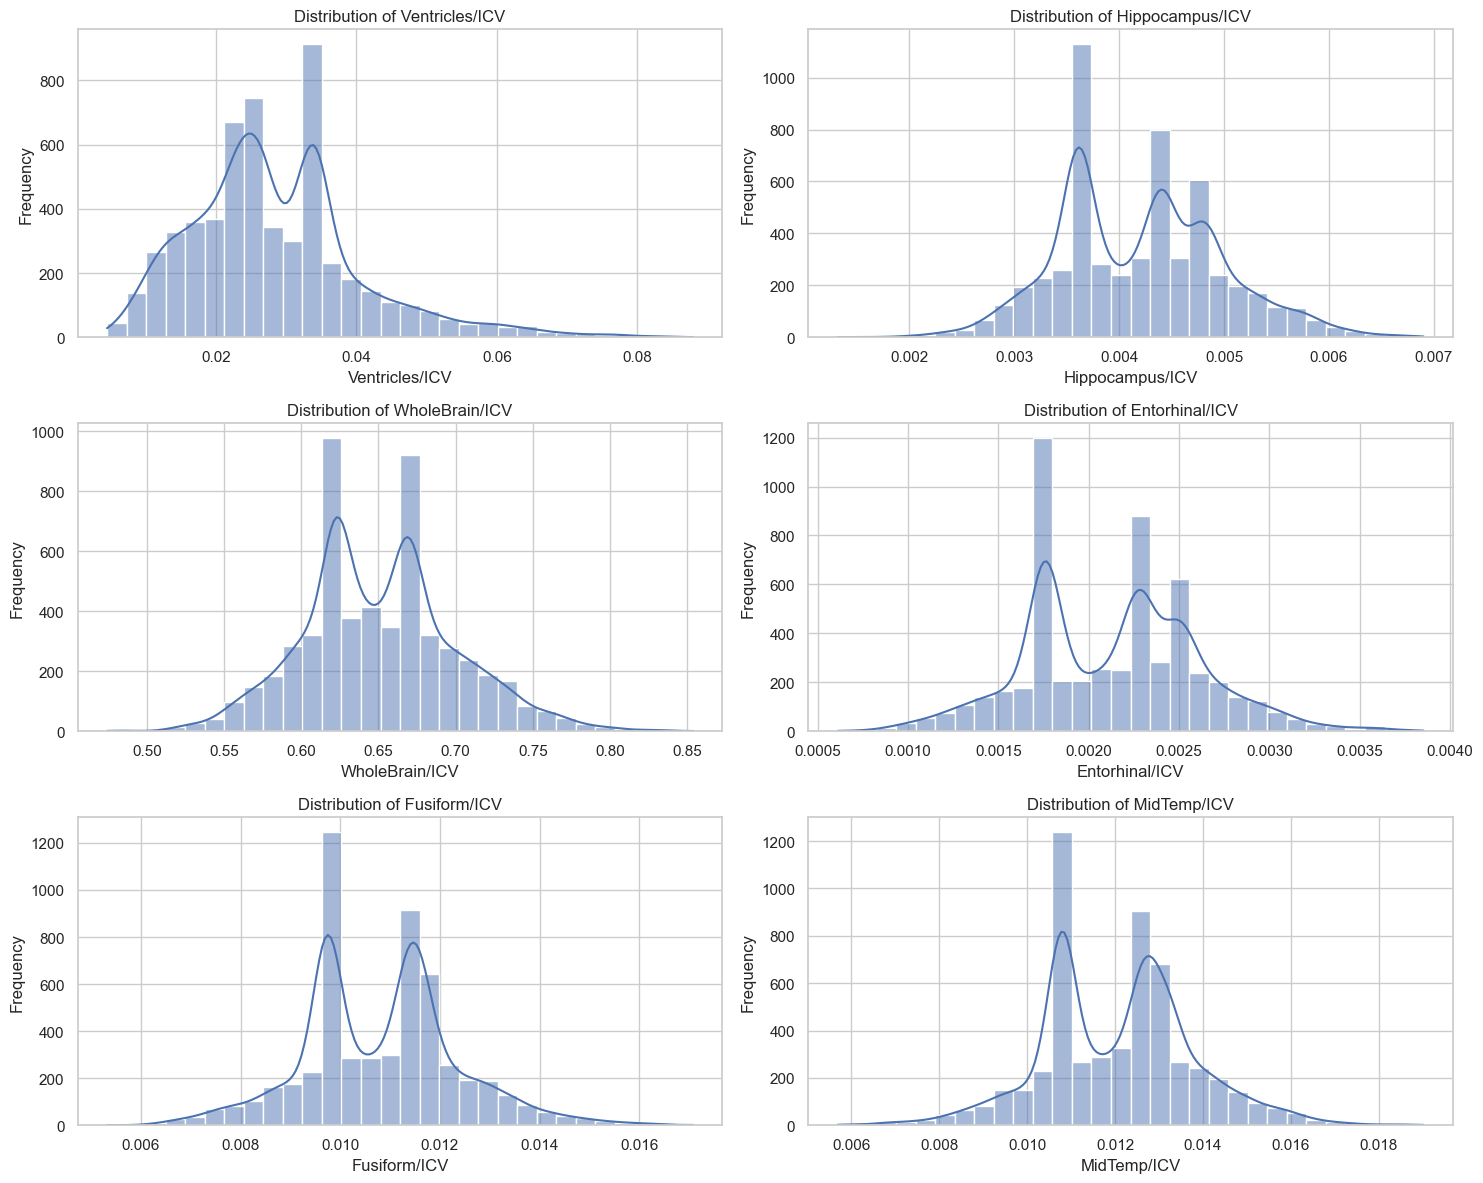

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of regions/columns to plot
regions = ['Ventricles/ICV', 'Hippocampus/ICV', 'WholeBrain/ICV',
           'Entorhinal/ICV', 'Fusiform/ICV', 'MidTemp/ICV']

# Set a style for the plots
sns.set(style="whitegrid")

# Plot distributions
plt.figure(figsize=(15, 12))
for i, region in enumerate(regions, 1):
    plt.subplot(3, 2, i)
    sns.histplot(AllDataset[region].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {region}')
    plt.xlabel(region)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [88]:
import time

# model_tensorization.load_weights('best_model_SavedInitialWeights_tensors.weights_new.h5')
model_tensorization.compile(loss=grouped_categorical_crossentropy, optimizer='adam', metrics=[grouped_categorical_accuracy])
# model_tensorization.save_weights('SavedInitialWeights_tensors.weights_new.h5')
callback_1 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=10, min_lr=1e-6, verbose=1)
callback_2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
# 
start_time = time.time()
History = model_tensorization.fit(X_train_here_4Net, Y_train_here_4Net, 
validation_split=0.15,  epochs=600, batch_size=64,
    verbose=1 , callbacks=[callback_2]) # , callbacks=[callback_1, callback_2]
elapsed_time = time.time() - start_time
print('----- train elapsed time:', elapsed_time)

Epoch 1/600
 1/67 [..............................] - ETA: 4:13 - loss: 0.1074 - grouped_categorical_accuracy: 0.6211

KeyboardInterrupt: 

In [152]:
import tensorflow as tf
import numpy as np
import time

# Define how many models you want in your ensemble
n_models = 25
ensemble_models = []

# Training loop for each model in the ensemble
for i in range(n_models):
    print(f"\nTraining model {i+1}/{n_models}...")
    
    # Clone a new instance of the base model
    model_tensorization = create_model()
    model_tensorization.compile(loss=grouped_categorical_crossentropy, 
                  optimizer='adam', 
                  metrics=[grouped_categorical_accuracy])
    
    callback_early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=50, restore_best_weights=True, verbose=1
    )
    callback_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.9, patience=10, min_lr=1e-6, verbose=1
    )

    start_time = time.time()
    model_tensorization.fit(
        X_train_here_4Net, Y_train_here_4Net, 
        validation_split=0.15, 
        epochs=600, 
        batch_size=64,
        verbose=1, 
        callbacks=[callback_early_stop, callback_reduce_lr]
    )
    elapsed_time = time.time() - start_time
    print(f'Model {i+1} training time: {elapsed_time:.2f} seconds')
    
    # Save the trained model to the ensemble list
    ensemble_models.append(model_tensorization)



Training model 1/25...
Epoch 1/600
68/68 [==============================] - 6s 42ms/step - loss: 0.8349 - grouped_categorical_accuracy: 0.5825 - val_loss: 0.8634 - val_grouped_categorical_accuracy: 0.7137 - lr: 0.0010
Epoch 2/600
68/68 [==============================] - 2s 32ms/step - loss: 0.6015 - grouped_categorical_accuracy: 0.7119 - val_loss: 0.7483 - val_grouped_categorical_accuracy: 0.7045 - lr: 0.0010
Epoch 3/600
68/68 [==============================] - 2s 26ms/step - loss: 0.5147 - grouped_categorical_accuracy: 0.7762 - val_loss: 0.6975 - val_grouped_categorical_accuracy: 0.7381 - lr: 0.0010
Epoch 4/600
68/68 [==============================] - 2s 29ms/step - loss: 0.4335 - grouped_categorical_accuracy: 0.8163 - val_loss: 0.6026 - val_grouped_categorical_accuracy: 0.7677 - lr: 0.0010
Epoch 5/600
68/68 [==============================] - 2s 27ms/step - loss: 0.3940 - grouped_categorical_accuracy: 0.8440 - val_loss: 0.5074 - val_grouped_categorical_accuracy: 0.8211 - lr: 0.0010
E

In [153]:
import os

# Assuming ensemble_models is a list of Keras models
# and you want to save each model to a specific directory
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

for idx, model in enumerate(ensemble_models):
    model_path = os.path.join(save_dir, f'ensemble_model_{idx}.h5')
    model.save(model_path)
    print(f'Model {idx} saved to {model_path}')


Model 0 saved to saved_models\ensemble_model_0.h5
Model 1 saved to saved_models\ensemble_model_1.h5
Model 2 saved to saved_models\ensemble_model_2.h5
Model 3 saved to saved_models\ensemble_model_3.h5
Model 4 saved to saved_models\ensemble_model_4.h5
Model 5 saved to saved_models\ensemble_model_5.h5
Model 6 saved to saved_models\ensemble_model_6.h5
Model 7 saved to saved_models\ensemble_model_7.h5
Model 8 saved to saved_models\ensemble_model_8.h5
Model 9 saved to saved_models\ensemble_model_9.h5
Model 10 saved to saved_models\ensemble_model_10.h5
Model 11 saved to saved_models\ensemble_model_11.h5
Model 12 saved to saved_models\ensemble_model_12.h5
Model 13 saved to saved_models\ensemble_model_13.h5
Model 14 saved to saved_models\ensemble_model_14.h5
Model 15 saved to saved_models\ensemble_model_15.h5
Model 16 saved to saved_models\ensemble_model_16.h5
Model 17 saved to saved_models\ensemble_model_17.h5
Model 18 saved to saved_models\ensemble_model_18.h5
Model 19 saved to saved_models\e

In [154]:
def ensemble_predict_with_uncertainty(models, X_input):
    # Collect all model predictions
    all_preds = np.array([model.predict(X_input) for model in models])  # Shape: (n_models, n_samples, n_classes)
    
    # Mean prediction (ensemble output)
    mean_preds = np.mean(all_preds, axis=0)  # Shape: (n_samples, n_classes)
    
    # Predictive uncertainty: variance across model outputs
    uncertainty = np.var(all_preds, axis=0)  # Shape: (n_samples, n_classes)
    
    return mean_preds, uncertainty


In [71]:
X_test_here_4Net=[X_all[0][test], X_all[1][test], X_all[2][test], X_all[3][test], X_all[4][test]]
Y_test_here_4Net=Y_all_tensors[test]
X_test_here_names=X_all_IDs[test]

In [86]:
X_all_IDs

array([   1,    2,    3, ..., 5614, 5615, 5616], dtype=int64)

In [85]:
X_test_here_names[0]

84

In [156]:
# Get predictions and uncertainties on test data
Y_pred_ensemble, Y_uncertainty = ensemble_predict_with_uncertainty(ensemble_models, X_test_here_4Net)

# # For each sample, get the predicted class and uncertainty for that class
# predicted_classes = np.argmax(Y_pred_ensemble, axis=1)
# uncertainty_scores = np.take_along_axis(Y_uncertainty, np.expand_dims(predicted_classes, axis=1), axis=1).squeeze()

# # Print example
# for i in range(5):
#     print(f"Sample {i}: predicted class = {predicted_classes[i]}, uncertainty = {uncertainty_scores[i]:.4f}")


18/18 [==============================] - 0s 7ms/step


In [157]:
Y_pred_ensemble[0]

array([0.00259229, 0.9959002 , 0.0015074 , 0.00732748, 0.97673166,
       0.01594083, 0.00873856, 0.9517015 , 0.0395598 , 0.02793911,
       0.8545881 , 0.11747274], dtype=float32)

In [158]:
Y_uncertainty[0]

array([5.4757656e-06, 1.6433241e-05, 6.0700386e-06, 3.2960885e-05,
       3.0683927e-04, 2.3274349e-04, 4.4108001e-05, 1.1678569e-03,
       1.1074162e-03, 2.7776067e-04, 4.5098085e-03, 4.7146333e-03],
      dtype=float32)

In [159]:
import numpy as np

# Assuming Y_uncertainty is already defined
max_value = np.max(Y_uncertainty)
min_value = np.min(Y_uncertainty)

print("Maximum value:", max_value)
print("Minimum value:", min_value)

Maximum value: 0.12281559
Minimum value: 0.0


In [ ]:
# model_tensorization.save("model_tensorization_for_paper_05-01-2025.h5")

In [129]:
from keras.models import load_model
model_tensorization = load_model('model_tensorization_for_paper_05-01-2025.h5', custom_objects={'grouped_softmax': grouped_softmax, 'grouped_categorical_crossentropy': grouped_categorical_crossentropy, 'grouped_categorical_accuracy': grouped_categorical_accuracy, 'MCDropout': MCDropout})

In [72]:
results = model_tensorization.evaluate(X_test_here_4Net, Y_test_here_4Net)
print(results)
output=model_tensorization.predict(X_test_here_4Net)

18/18 [==============================] - 0s 5ms/step - loss: 0.0716 - grouped_categorical_accuracy: 0.5257
[0.0715528130531311, 0.5256696343421936]
18/18 [==============================] - 0s 4ms/step


In [81]:
Y_train_here_4Net[0]

array([1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.])

In [73]:
y_true = np.reshape(Y_test_here_4Net,(len(Y_test_here_4Net),4,3)).transpose(0, 2, 1)
y_true[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
# Y_pred_ensemble = np.round(output, 2)
# y_pred = np.reshape(output,(len(output),4,3)).transpose(0, 2, 1)
# y_pred[0]

array([[9.3033013e-05, 4.7533185e-04, 6.7293260e-04, 4.8112585e-03],
       [9.9990696e-01, 9.9952465e-01, 9.9932700e-01, 9.9518865e-01],
       [3.3500140e-21, 1.9481216e-19, 1.0312215e-16, 1.1846021e-20]],
      dtype=float32)

In [161]:
Y_pred_ensemble = np.round(Y_pred_ensemble, 2)
y_pred = np.reshape(Y_pred_ensemble,(len(Y_pred_ensemble),4,3)).transpose(0, 2, 1)
y_pred[0]

array([[0.  , 0.01, 0.01, 0.03],
       [1.  , 0.98, 0.95, 0.85],
       [0.  , 0.02, 0.04, 0.12]], dtype=float32)

In [162]:
Y_uncertainty = np.round(Y_uncertainty, 2)
y_var = np.reshape(Y_uncertainty,(len(Y_uncertainty),4,3)).transpose(0, 2, 1)
y_var[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)

In [75]:
y_true_img = create_image(y_true)
y_true_img[53,:,:,:]


array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def plot_output(img, y, title, var=None):
    if var is None or np.isscalar(var):
        var = np.zeros_like(y)

    plt.imshow(img)
    plt.title(title)

    # Set x-axis ticks and labels
    x_ticks = [0, 1, 2, 3]
    x_labels = ["T0", "T6", "T12", "T24"]
    plt.xticks(x_ticks, x_labels)

    # Set y-axis ticks and labels
    y_ticks = [0, 1, 2]
    y_labels = ["CN", "MCI", "AD"]
    plt.yticks(y_ticks, y_labels)

    plt.ylim(2.5, -1)

    if title == "Predicted":
        plt.axhspan(-1, -0.5, facecolor='gold', zorder=0)
    else:
        plt.axhspan(-1, -0.5, facecolor='gold', hatch='///', edgecolor='black', zorder=0)

    # Grid lines
    for x in range(1, len(x_ticks)):
        plt.axvline(x=x - 0.5, color='silver', linewidth=1)
    plt.axhline(y=0.495, color='gray', linestyle='--', linewidth=0.25)
    plt.axhline(y=1.495, color='gray', linestyle='--', linewidth=0.25)
    plt.axhline(y=-0.495, color='gray', linestyle='--', linewidth=0.25)

    # Show main label values
    for i in range(y.shape[1]):       # Time (x-axis)
        for j in range(y.shape[0]):   # Class (y-axis)
            label = y[j, i]
            if label is not None and label > 0:
                plt.text(i, j, f"{label:.2f}", color='white', fontsize=7, ha='center', va='center')

    # Safely reshape var to match (classes, timepoints)
    try:
        reshaped_var = var.reshape((3, -1))  # Assuming 3 classes
        for i in range(reshaped_var.shape[1]):  # Iterate over timepoints
            max_uncertainty = np.max(reshaped_var[:, i])
            if title == "Predicted":
                plt.text(i, -0.75, f"{np.exp(-5*max_uncertainty):.2f}", color='black', fontsize=7, ha='center', va='center')
    except:
        print("Warning: Could not reshape or interpret 'var' for uncertainty strip.")

    # Set plot limits
    

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor('silver')
        spine.set_linewidth(1)


In [78]:
y_true[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

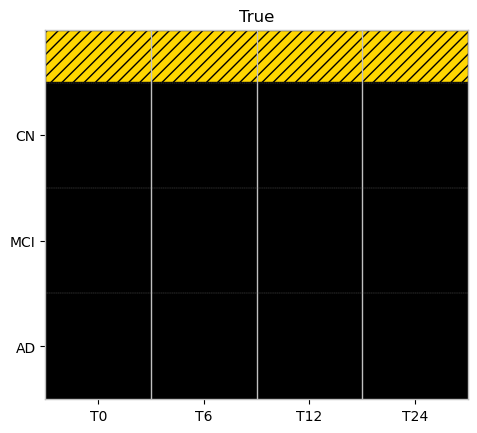

In [77]:
plot_output(y_true_img[0, :, :, :],y_true[0], "True" )

In [166]:
y_pred_img = create_image(y_pred)
y_pred_img[0,:,:,:]


array([[[0.        , 0.        , 0.        ],
        [0.        , 0.01      , 0.        ],
        [0.        , 0.01      , 0.        ],
        [0.        , 0.03      , 0.        ]],

       [[0.        , 0.        , 1.        ],
        [0.        , 0.        , 0.98000002],
        [0.        , 0.        , 0.94999999],
        [0.        , 0.        , 0.85000002]],

       [[0.        , 0.        , 0.        ],
        [0.02      , 0.        , 0.        ],
        [0.04      , 0.        , 0.        ],
        [0.12      , 0.        , 0.        ]]])

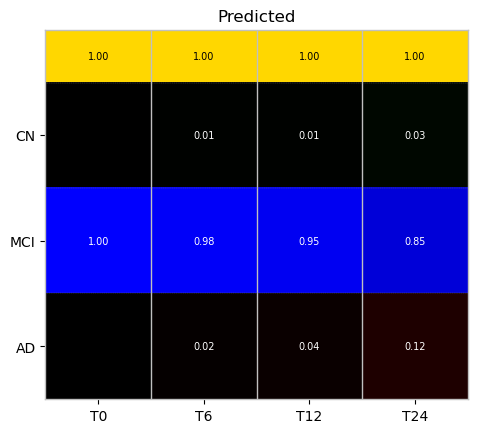

In [167]:
plot_output(y_pred_img[0,:,:,:],y_pred[0], "Predicted", y_var[0])

In [168]:
X_test_here_names

array([4289, 2322, 3049, 1272, 2022, 3853, 4953,  195,  724, 1896,  346,
       4828, 1788, 3533, 2017, 4682,  957, 1700, 2265, 2589, 2749, 4390,
        408,   84, 3351, 3546, 1742, 3127,  664, 1422, 4160,   57, 2377,
       2845, 4834, 5265,   55, 1858, 2168, 5237, 2040, 3327, 4780, 3499,
        666, 2792,  162, 4835, 3690, 3236, 3833, 1060, 5200, 5312, 2878,
       2800, 4762,  247, 2538, 4216, 2210, 4092, 4116, 2316, 1058, 1499,
       1972, 2831,  290,  116, 3873,  434, 4905, 3880, 3644, 3424, 2651,
       5456, 4716, 2452,  474, 1789, 1537, 4635, 3672, 5156, 3709,  150,
       5104,  758, 5044, 2497,  360,  736, 4108, 2605, 4802, 1210, 3896,
       1451,  826, 4469, 2029, 2254, 5235, 2451, 2300, 1525, 3022,  906,
       3547, 1351, 1460, 2587, 5267, 1282, 1137, 4935, 3737, 2745, 4678,
       2828, 1283, 4640,  733, 4943, 3904, 3290, 2977, 5060, 4880, 2407,
        988, 5144, 1885, 4539, 4741, 1687, 5574, 3434,  894, 3352, 3367,
       3003, 2744, 3431,  306, 5345, 1011,  742,  7

In [158]:
X_test_here_names[406]

1336

In [ ]:
AllDataset.iloc[4333]

ID               4334
RID              4357
PTID       006_S_4357
VISCODE            48
SITE                6
              ...    
DX6                CN
12            4357m60
DX12               CN
24            4357m72
DX24               CN
Name: 4334, Length: 69, dtype: object

In [ ]:
AllDataset.iloc[X_test_here_names[5]]["ID"]

3854

In [62]:
y_true_img[570,:,:,:]

IndexError: index 570 is out of bounds for axis 0 with size 566

In [63]:
y_pred_img[570, :, :, :]

IndexError: index 570 is out of bounds for axis 0 with size 566

In [69]:
output[11]

array([0.  , 0.53, 0.47, 0.  , 0.41, 0.59, 0.  , 0.28, 0.72, 0.  , 0.12,
       0.88], dtype=float32)

In [70]:
X_test_here_names[11]

4828

C:\Users\14792\AppData\Local\Temp\ipykernel_372\115712419.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


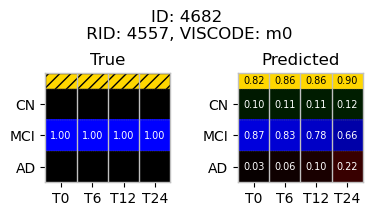

In [169]:
index = 15
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
id = X_test_here_names[index]
rid = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]
t_period = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'VISCODE'].values[0]
fig.suptitle(f"ID: {id}\n RID: {rid}, VISCODE: m{t_period}")

plt.sca(axes[0])
plot_output(y_true_img[index, :, :, :], y_true[index], "True")

plt.sca(axes[1])
plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted", y_var[index])

fig.tight_layout()  # reserve space for suptitle
fig.savefig(f"output_{id}.png", dpi=300, bbox_inches='tight')
fig.show()

In [196]:
Y_test_here_4Net[570]

IndexError: index 570 is out of bounds for axis 0 with size 566

In [95]:
len(X_test_here_names)

571

In [96]:
AllDataset.head()

,ID,RID,PTID,VISCODE,SITE,COLPROT,ORIGPROT,EXAMDATE,DX_bl,AGE,...,ICV,Unnamed: 60,Unnamed: 61,DX,6,DX6,12,DX12,24,DX24
ID,,,,,,,,,,,,,,,,,,,,,
1,1,2,011_S_0002,0,11,ADNI1,ADNI1,38603,CN,74.3000,...,1984660.0000,0,2m0,CN,2m6,CN,2m12,CN,2m24,CN
2,2,2,011_S_0002,6,11,ADNI1,ADNI1,38782,CN,74.8000,...,1516962.1113,6,2m6,CN,2m12,CN,2m18,CN,2m30,CN
3,3,2,011_S_0002,36,11,ADNI1,ADNI1,39687,CN,77.3000,...,1516962.1113,36,2m36,CN,2m42,CN,2m48,CN,2m60,CN
4,4,2,011_S_0002,60,11,ADNIGO,ADNI1,40443,CN,79.3000,...,1516962.1113,60,2m60,CN,2m66,CN,2m72,CN,2m84,MCI
5,5,2,011_S_0002,72,11,ADNI2,ADNI1,40805,CN,80.3000,...,1516962.1113,72,2m72,CN,2m78,CN,2m84,CN,2m96,CN


In [97]:
AllDataset.loc[AllDataset['ID'] == X_test_here_names[50], 'VISCODE']

ID
1210    0
Name: VISCODE, dtype: int64

In [171]:
for index in range(len(X_test_here_names)):
    fig, axes = plt.subplots(1, 2, figsize=(4,2))
    id = X_test_here_names[index]
    rid = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]
    t_period = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'VISCODE'].values[0]
    fig.suptitle(f"ID: {id}\n RID: {rid}, VISCODE: m{t_period}")

    plt.sca(axes[0])
    plot_output(y_true_img[index, :, :, :], y_true[index], "True")

    plt.sca(axes[1])
    plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted", y_var[index])
    
    fig.tight_layout()  # reserve space for suptitle
    fig.savefig(f"test_images_imputed_with_ensemble/{rid}_{t_period}.jpg", format='jpg', dpi=300, bbox_inches='tight')
    plt.close(fig)


In [115]:
a = np.array([[[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

aa = np.array([[1., 1., 1., 1.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

b = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 1.],
            [0., 0., 1.],
            [0., 0., 1.],
            [0., 0., 1.]],

           [[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]]])

bb = np.array([[0., 0., 0., 0.],
               [1., 1., 1., 1.],
                [0., 0., 0., 0.]])


c = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[1., 0., 0.],
            [1., 0., 0.],
            [1., 0., 0.],
            [1., 0., 0.]]])

cc = np.array([[0., 0., 0., 0.],
                [0., 0., 0., 0.],
                [1., 1., 1., 1.],])

d = np.array([[[0., 1., 0.],
        [0., .75, 0.],
        [0., .48, 0.],
        [0., .05, 0.]],

       [[0., 0., 0.],
        [0., 0., .25],
        [0., 0., .52],
        [0., 0., .95]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

dd = np.array([[1., .75, .48, .05],
               [0., 0.25, .52, .95],
                [0., 0., 0., 0.],])

e = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 1.],
            [0., 0., 0.9],
            [0., 0., 0.73],
            [0., 0., 0.55]],

           [[0., 0., 0.],
            [.1, 0., 0.],
            [.27, 0., 0.],
            [.45, 0., 0.]]])

ee = np.array([[0, 0 , 0., 0.],
               [1., 0.9, .73, .55],
                [0., 0.1, 0.27, .45],])


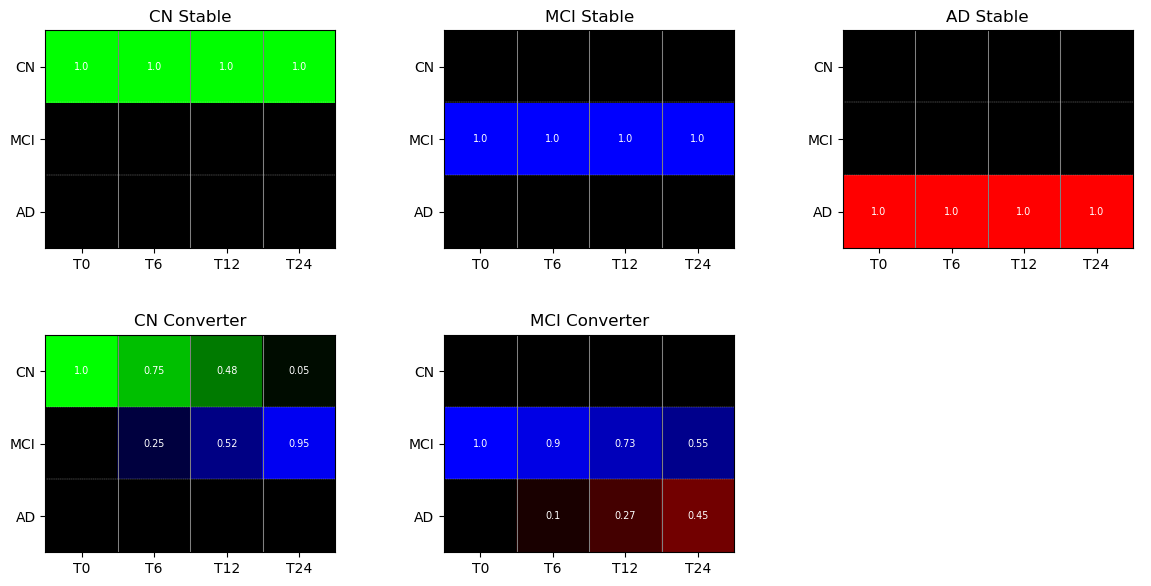

In [116]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# First row
plt.sca(axes[0,0])
plot_output(a, aa, "CN Stable")

plt.sca(axes[0,1])
plot_output(b, bb, "MCI Stable")

plt.sca(axes[0,2])
plot_output(c, cc, "AD Stable")

# Second row
plt.sca(axes[1,0])
plot_output(d, dd, "CN Converter")

plt.sca(axes[1,1])
plot_output(e, ee, "MCI Converter")

# Hide unused subplot
axes[1,2].axis('off')

# Improve spacing
plt.subplots_adjust(
    left=0.05,    # space from left edge
    right=0.97,   # space from right edge
    top=0.95,     # space from top
    bottom=0.08,  # space from bottom
    wspace=0.3,   # width space between subplots
    hspace=0.4    # height space between subplots
)

plt.show()
